<a href="https://colab.research.google.com/github/Lornatt88/maai901-vision-project/blob/main/notebooks/02_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Loading everything**

In [1]:
import os
import pandas as pd
import torch
import kagglehub
from google.colab import drive

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
drive.mount("/content/drive")

save_dir = "/content/drive/MyDrive/maai901_skin"
train_df = pd.read_csv(os.path.join(save_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(save_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(save_dir, "test.csv"))

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("First image found:", os.path.exists(train_df["path"].iloc[0]))
print("GPU on:", torch.cuda.is_available())

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Mounted at /content/drive
Train: 2566 | Val: 542 | Test: 544
First image found: True
GPU on: True


### **Building the data pipeline**

**How:**
- Resize to 224 x 224 pixels: the size ViT and ResNet expect.

- Augmentation (training only): random flips and small rotations. A mole flipped upside down is still a mole, so this teaches the model to focus on the lesion, not its position. It also gives the model more variety without new photos.

- Normalise: adjusts the colour values to the scale the model was originally trained on.

In [2]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

classes = ["nv", "bkl", "mel", "bcc"]
class_to_idx = {c: i for i, c in enumerate(classes)}

class SkinDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["path"].tolist()
        self.labels = [class_to_idx[d] for d in df["dx"]]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), self.labels[i]

def make_loaders(mean, std, batch_size=32):
    train_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    train_loader = DataLoader(SkinDataset(train_df, train_tf), batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(SkinDataset(val_df, eval_tf), batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(SkinDataset(test_df, eval_tf), batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("First 10 labels:", labels[:10])

Batch shape: torch.Size([32, 3, 224, 224])
First 10 labels: tensor([3, 1, 1, 1, 2, 0, 1, 1, 1, 1])


### **The training code**

**balanced accuracy:** for each class, the % of real cases the model caught (that's called recall, or sensitivity in medicine). Then we average the 4.

In [3]:
import torch.nn as nn
import numpy as np
from sklearn.metrics import recall_score
import time, copy

device = "cuda"

counts = train_df["dx"].value_counts()
weights = torch.tensor([len(train_df) / (4 * counts[c]) for c in classes], dtype=torch.float).to(device)
print("Class weights:", dict(zip(classes, weights.cpu().numpy().round(2))))

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, preds, trues = 0, [], []
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            if hasattr(out, "logits"):
                out = out.logits
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            preds += out.argmax(1).cpu().tolist()
            trues += y.cpu().tolist()
    acc = np.mean(np.array(preds) == np.array(trues))
    bal = recall_score(trues, preds, average="macro")
    return total_loss / len(loader.dataset), acc, bal

def train_model(model, train_loader, val_loader, lr, epochs, name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    best_bal, best_state, history = 0, None, []
    for ep in range(1, epochs + 1):
        start = time.time()
        tr = run_epoch(model, train_loader, criterion, optimizer)
        va = run_epoch(model, val_loader, criterion)
        history.append({"epoch": ep, "train_loss": tr[0], "train_acc": tr[1], "train_bal_acc": tr[2],
                        "val_loss": va[0], "val_acc": va[1], "val_bal_acc": va[2]})
        print(f"Epoch {ep}/{epochs} | train loss {tr[0]:.3f} bal-acc {tr[2]:.3f} | "
              f"val loss {va[0]:.3f} bal-acc {va[2]:.3f} | {time.time() - start:.0f}s")
        if va[2] > best_bal:
            best_bal = va[2]
            best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    torch.save(best_state, os.path.join(save_dir, f"{name}.pt"))
    pd.DataFrame(history).to_csv(os.path.join(save_dir, f"{name}_history.csv"), index=False)
    print(f"Best validation balanced accuracy: {best_bal:.3f} | saved {name}.pt")
    return model

Class weights: {'nv': np.float32(0.98), 'bkl': np.float32(0.83), 'mel': np.float32(0.84), 'bcc': np.float32(1.71)}


### **Training Model 1, the frozen ViT**

**What we're doing:**

- Loading the ready-made ViT from Hugging Face (google/vit-base-patch16-224). It was trained on millions of everyday photos.
Replacing its last layer with a new one that outputs our 4 classes, instead of the 1,000 everyday categories it originally knew.

- Freezing everything except that new last layer.
"Freezing" = locking the model's settings so they can't change. Only the new layer learns.

In [ ]:
from transformers import ViTForImageClassification

vit_frozen = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=4,
    ignore_mismatched_sizes=True,
)

for name, param in vit_frozen.named_parameters():
    param.requires_grad = "classifier" in name

trainable = sum(p.numel() for p in vit_frozen.parameters() if p.requires_grad)
total = sum(p.numel() for p in vit_frozen.parameters())
print(f"Trainable settings: {trainable:,} out of {total:,}")

vit_frozen = train_model(vit_frozen, train_loader, val_loader, lr=1e-3, epochs=10, name="vit_frozen")

***Already ran this once and saved the results in (vit_frozen) on Google Drive.***

### **Train Model 2, the fully fine-tuned ViT**
**What we're doing:**

Same ViT, but this time nothing is frozen. All 86 million settings can adjust to skin images.

Three changes from Model 1:

- Smaller learning rate (0.00002 instead of 0.001): the model already knows a lot. Big steps would wreck what it learned from millions of photos. Small steps let it adjust gently. This is the standard setting for fine-tuning ViTs.

- Smaller batches (16 instead of 32 images per tray): training the whole model uses much more GPU memory. Smaller trays stop Colab from running out of memory and crashing.

- Clearing Model 1 from memory first: it's already saved in my Drive, so I remove it from the GPU to make room.

In [5]:
if "vit_frozen" in globals():
    del vit_frozen
torch.cuda.empty_cache()

train_loader, val_loader, test_loader = make_loaders([0.5, 0.5, 0.5], [0.5, 0.5, 0.5], batch_size=16)

vit_finetuned = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=4,
    ignore_mismatched_sizes=True,
)

trainable = sum(p.numel() for p in vit_finetuned.parameters() if p.requires_grad)
print(f"Trainable settings: {trainable:,}")

vit_finetuned = train_model(vit_finetuned, train_loader, val_loader, lr=2e-5, epochs=10, name="vit_finetuned")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Trainable settings: 85,801,732
Epoch 1/10 | train loss 0.791 bal-acc 0.680 | val loss 0.650 bal-acc 0.768 | 98s
Epoch 2/10 | train loss 0.447 bal-acc 0.836 | val loss 0.649 bal-acc 0.707 | 98s
Epoch 3/10 | train loss 0.319 bal-acc 0.887 | val loss 0.611 bal-acc 0.752 | 99s
Epoch 4/10 | train loss 0.221 bal-acc 0.924 | val loss 0.579 bal-acc 0.763 | 99s
Epoch 5/10 | train loss 0.162 bal-acc 0.947 | val loss 0.603 bal-acc 0.756 | 98s
Epoch 6/10 | train loss 0.115 bal-acc 0.966 | val loss 0.626 bal-acc 0.798 | 99s
Epoch 7/10 | train loss 0.088 bal-acc 0.973 | val loss 0.677 bal-acc 0.765 | 98s
Epoch 8/10 | train loss 0.051 bal-acc 0.989 | val loss 0.656 bal-acc 0.806 | 98s
Epoch 9/10 | train loss 0.049 bal-acc 0.983 | val loss 0.674 bal-acc 0.794 | 98s
Epoch 10/10 | train loss 0.047 bal-acc 0.986 | val loss 0.752 bal-acc 0.807 | 98s
Best validation balanced accuracy: 0.807 | saved vit_finetuned.pt


### **Train Model 3, ResNet-50**

**What we're doing:**

- Training the CNN (ResNet-50) the same way as Model 2: the whole model learns, same training routine, same 10 epochs. That way, the only real difference is the model type, ViT vs CNN.

**What's different from Model 2 and why:**

- Different colour settings: ResNet was originally trained with slightly different colour values than ViT, so we use its own.
- Bigger new last layer: ResNet describes each image with 2,048 numbers (ViT used 768) so the new last layer turns 2,048 numbers into the 4 scores.
- Learning rate 0.0001: the normal fine-tuning step size for ResNet.
- Trays of 32 images: ResNet uses less memory than ViT, so it can handle more at once.

In [4]:
if "vit_finetuned" in globals():
    del vit_finetuned
torch.cuda.empty_cache()

from torchvision import models

train_loader, val_loader, test_loader = make_loaders(
    [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], batch_size=32
)

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Linear(resnet.fc.in_features, 4)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Trainable settings: {trainable:,}")

resnet = train_model(resnet, train_loader, val_loader, lr=1e-4, epochs=10, name="resnet50_finetuned")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 106MB/s]


Trainable settings: 23,516,228
Epoch 1/10 | train loss 0.927 bal-acc 0.648 | val loss 0.767 bal-acc 0.711 | 45s
Epoch 2/10 | train loss 0.556 bal-acc 0.786 | val loss 0.608 bal-acc 0.769 | 42s
Epoch 3/10 | train loss 0.388 bal-acc 0.857 | val loss 0.718 bal-acc 0.750 | 38s
Epoch 4/10 | train loss 0.317 bal-acc 0.884 | val loss 0.991 bal-acc 0.712 | 39s
Epoch 5/10 | train loss 0.266 bal-acc 0.900 | val loss 0.874 bal-acc 0.753 | 37s
Epoch 6/10 | train loss 0.211 bal-acc 0.927 | val loss 0.766 bal-acc 0.750 | 38s
Epoch 7/10 | train loss 0.191 bal-acc 0.931 | val loss 0.606 bal-acc 0.800 | 39s
Epoch 8/10 | train loss 0.170 bal-acc 0.940 | val loss 0.926 bal-acc 0.782 | 37s
Epoch 9/10 | train loss 0.161 bal-acc 0.943 | val loss 0.869 bal-acc 0.762 | 38s
Epoch 10/10 | train loss 0.146 bal-acc 0.950 | val loss 0.913 bal-acc 0.753 | 38s
Best validation balanced accuracy: 0.800 | saved resnet50_finetuned.pt


### **Now, testing all 3 models**

In [5]:
import torch.nn.functional as F
from transformers import ViTForImageClassification
from torchvision import models
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score,
                             roc_auc_score, classification_report)

def get_probs(model, loader):
    model.eval()
    probs, trues = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            if hasattr(out, "logits"):
                out = out.logits
            probs.append(F.softmax(out, dim=1).cpu())
            trues += y.tolist()
    return torch.cat(probs).numpy(), np.array(trues)

def load_vit(name):
    m = ViTForImageClassification.from_pretrained(
        "google/vit-base-patch16-224", num_labels=4, ignore_mismatched_sizes=True)
    m.load_state_dict(torch.load(os.path.join(save_dir, f"{name}.pt")))
    return m.to(device)

def load_resnet():
    m = models.resnet50()
    m.fc = nn.Linear(2048, 4)
    m.load_state_dict(torch.load(os.path.join(save_dir, "resnet50_finetuned.pt")))
    return m.to(device)

vit_norm = ([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
res_norm = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

setups = [
    ("ViT frozen", lambda: load_vit("vit_frozen"), vit_norm),
    ("ViT fine-tuned", lambda: load_vit("vit_finetuned"), vit_norm),
    ("ResNet-50 fine-tuned", load_resnet, res_norm),
]

names = ["Mole (nv)", "Benign keratosis (bkl)", "Melanoma (mel)", "Basal cell carcinoma (bcc)"]
results, all_probs = [], {}

for model_name, load_fn, (mean, std) in setups:
    _, _, test_loader = make_loaders(mean, std)
    model = load_fn()
    probs, trues = get_probs(model, test_loader)
    preds = probs.argmax(1)
    all_probs[model_name] = (probs, trues)

    rec = recall_score(trues, preds, average=None)
    cancer = np.isin(trues, [2, 3])
    cancer_caught = np.isin(preds[cancer], [2, 3]).mean()

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(trues, preds),
        "Balanced acc": balanced_accuracy_score(trues, preds),
        "Macro AUC": roc_auc_score(trues, probs, multi_class="ovr", average="macro"),
        "Recall nv": rec[0], "Recall bkl": rec[1],
        "Recall mel": rec[2], "Recall bcc": rec[3],
        "Cancer caught": cancer_caught,
    })

    print(f"\n===== {model_name} =====")
    print(classification_report(trues, preds, target_names=names, digits=3))
    del model
    torch.cuda.empty_cache()

results_df = pd.DataFrame(results).round(3)
results_df.to_csv(os.path.join(save_dir, "test_results.csv"), index=False)
display(results_df)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...


===== ViT frozen =====
                            precision    recall  f1-score   support

                 Mole (nv)      0.740     0.641     0.687       142
    Benign keratosis (bkl)      0.663     0.678     0.671       171
            Melanoma (mel)      0.618     0.637     0.628       168
Basal cell carcinoma (bcc)      0.671     0.778     0.721        63

                  accuracy                          0.667       544
                 macro avg      0.673     0.683     0.676       544
              weighted avg      0.670     0.667     0.667       544



Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



===== ViT fine-tuned =====
                            precision    recall  f1-score   support

                 Mole (nv)      0.757     0.768     0.762       142
    Benign keratosis (bkl)      0.778     0.719     0.748       171
            Melanoma (mel)      0.679     0.655     0.667       168
Basal cell carcinoma (bcc)      0.713     0.905     0.797        63

                  accuracy                          0.733       544
                 macro avg      0.732     0.762     0.743       544
              weighted avg      0.734     0.733     0.732       544


===== ResNet-50 fine-tuned =====
                            precision    recall  f1-score   support

                 Mole (nv)      0.810     0.690     0.745       142
    Benign keratosis (bkl)      0.826     0.749     0.785       171
            Melanoma (mel)      0.688     0.815     0.747       168
Basal cell carcinoma (bcc)      0.812     0.889     0.848        63

                  accuracy                       

,Model,Accuracy,Balanced acc,Macro AUC,Recall nv,Recall bkl,Recall mel,Recall bcc,Cancer caught
0,ViT frozen,0.667,0.683,0.893,0.641,0.678,0.637,0.778,0.723
1,ViT fine-tuned,0.733,0.762,0.931,0.768,0.719,0.655,0.905,0.749
2,ResNet-50 fine-tuned,0.770,0.786,0.939,0.690,0.749,0.815,0.889,0.861


### **Confusion matrices**

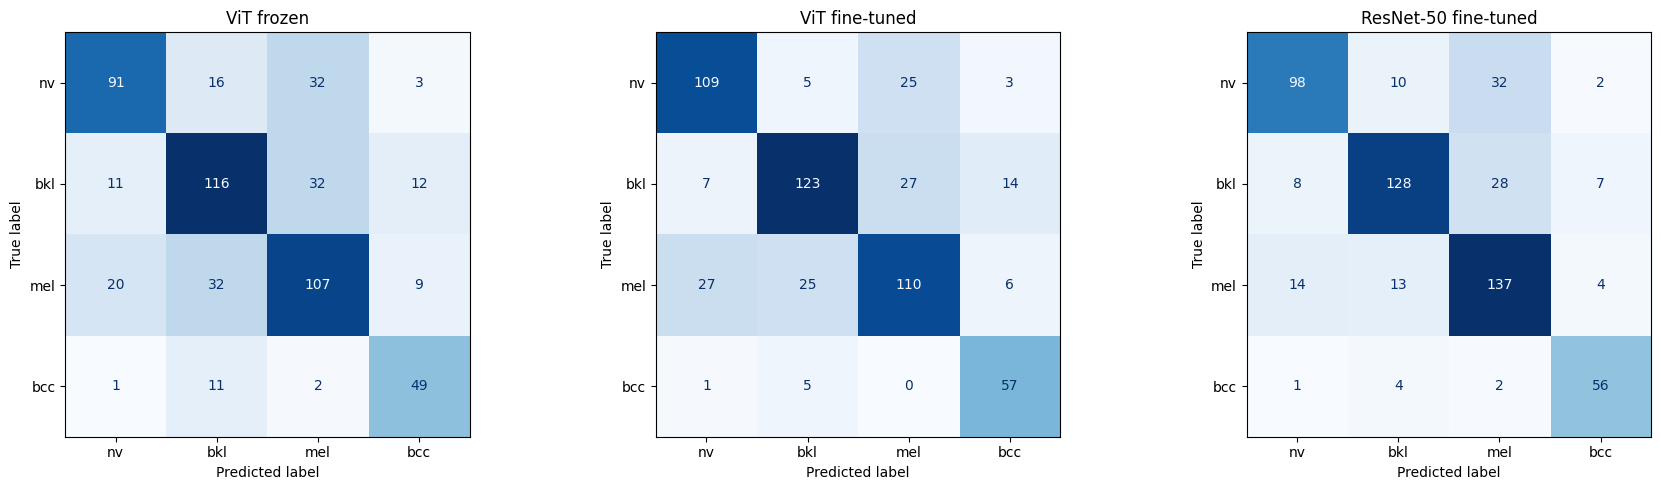

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

short = ["nv", "bkl", "mel", "bcc"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, (probs, trues)) in zip(axes, all_probs.items()):
    cm = confusion_matrix(trues, probs.argmax(1))
    ConfusionMatrixDisplay(cm, display_labels=short).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "confusion_matrices.png"), dpi=150)
plt.show()

### **Setting up the improved training recipe**

**The 5 changes:**

- Stronger augmentation: besides flips and rotation, each training image now gets a random slight zoom and slight changes in brightness, contrast and colour. It's harder to memorise images that look a bit different every time. (Colour changes are kept small, because colour matters for diagnosing skin lesions.)

- Weight decay (0.05): gently stops the model from relying too heavily on any single setting.

- Label smoothing (0.1): stops the model from being 100% certain.

- Learning rate schedule: starts with small steps for the first epoch (warm-up), then gradually reduces the step size towards the end.

- Early stopping: up to 15 epochs, but if validation doesn't improve for 4 epochs in a row, training stops automatically. No wasted time, less memorising.

In [7]:
import math
from torch.optim.lr_scheduler import LambdaLR

def make_loaders_v2(mean, std, batch_size=32):
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    train_loader = DataLoader(SkinDataset(train_df, train_tf), batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(SkinDataset(val_df, eval_tf), batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(SkinDataset(test_df, eval_tf), batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader

def run_epoch_v2(model, loader, criterion, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, preds, trues = 0, [], []
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            if hasattr(out, "logits"):
                out = out.logits
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * x.size(0)
            preds += out.argmax(1).cpu().tolist()
            trues += y.cpu().tolist()
    acc = np.mean(np.array(preds) == np.array(trues))
    bal = recall_score(trues, preds, average="macro")
    return total_loss / len(loader.dataset), acc, bal

def train_model_v2(model, train_loader, val_loader, lr, name, max_epochs=15, patience=4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=0.05)

    total_steps = max_epochs * len(train_loader)
    warmup_steps = len(train_loader)
    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    scheduler = LambdaLR(optimizer, lr_lambda)

    best_bal, best_state, history, no_improve = 0, None, [], 0
    for ep in range(1, max_epochs + 1):
        start = time.time()
        tr = run_epoch_v2(model, train_loader, criterion, optimizer, scheduler)
        va = run_epoch_v2(model, val_loader, criterion)
        history.append({"epoch": ep, "train_loss": tr[0], "train_acc": tr[1], "train_bal_acc": tr[2],
                        "val_loss": va[0], "val_acc": va[1], "val_bal_acc": va[2]})
        print(f"Epoch {ep}/{max_epochs} | train loss {tr[0]:.3f} bal-acc {tr[2]:.3f} | "
              f"val loss {va[0]:.3f} bal-acc {va[2]:.3f} | {time.time() - start:.0f}s")
        if va[2] > best_bal:
            best_bal, best_state, no_improve = va[2], copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping: no improvement for {patience} epochs.")
                break
    model.load_state_dict(best_state)
    torch.save(best_state, os.path.join(save_dir, f"{name}.pt"))
    pd.DataFrame(history).to_csv(os.path.join(save_dir, f"{name}_history.csv"), index=False)
    print(f"Best validation balanced accuracy: {best_bal:.3f} | saved {name}.pt")
    return model

print("Improved recipe ready.")

Improved recipe ready.


### **Training the improved ViT**

In [8]:
torch.cuda.empty_cache()

train_loader, val_loader, test_loader = make_loaders_v2([0.5, 0.5, 0.5], [0.5, 0.5, 0.5], batch_size=16)

vit_v2 = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=4,
    ignore_mismatched_sizes=True,
)

vit_v2 = train_model_v2(vit_v2, train_loader, val_loader, lr=2e-5, name="vit_finetuned_v2")

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 1/15 | train loss 1.129 bal-acc 0.546 | val loss 1.012 bal-acc 0.678 | 114s
Epoch 2/15 | train loss 0.804 bal-acc 0.772 | val loss 0.882 bal-acc 0.762 | 111s
Epoch 3/15 | train loss 0.696 bal-acc 0.833 | val loss 0.837 bal-acc 0.741 | 111s
Epoch 4/15 | train loss 0.624 bal-acc 0.878 | val loss 0.830 bal-acc 0.781 | 111s
Epoch 5/15 | train loss 0.576 bal-acc 0.899 | val loss 0.800 bal-acc 0.791 | 111s
Epoch 6/15 | train loss 0.533 bal-acc 0.932 | val loss 0.824 bal-acc 0.782 | 112s
Epoch 7/15 | train loss 0.488 bal-acc 0.954 | val loss 0.825 bal-acc 0.788 | 112s
Epoch 8/15 | train loss 0.454 bal-acc 0.974 | val loss 0.834 bal-acc 0.787 | 111s
Epoch 9/15 | train loss 0.452 bal-acc 0.970 | val loss 0.834 bal-acc 0.787 | 111s
Early stopping: no improvement for 4 epochs.
Best validation balanced accuracy: 0.791 | saved vit_finetuned_v2.pt


### **Training the improved ResNet-50**

In [9]:
if "vit_v2" in globals():
    del vit_v2
torch.cuda.empty_cache()

train_loader, val_loader, test_loader = make_loaders_v2(
    [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], batch_size=32
)

resnet_v2 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet_v2.fc = nn.Linear(resnet_v2.fc.in_features, 4)

resnet_v2 = train_model_v2(resnet_v2, train_loader, val_loader, lr=1e-4, name="resnet50_finetuned_v2")

Epoch 1/15 | train loss 1.271 bal-acc 0.489 | val loss 1.008 bal-acc 0.663 | 51s
Epoch 2/15 | train loss 0.850 bal-acc 0.752 | val loss 0.842 bal-acc 0.760 | 52s
Epoch 3/15 | train loss 0.733 bal-acc 0.806 | val loss 0.864 bal-acc 0.770 | 50s
Epoch 4/15 | train loss 0.670 bal-acc 0.843 | val loss 0.884 bal-acc 0.767 | 54s
Epoch 5/15 | train loss 0.622 bal-acc 0.869 | val loss 0.880 bal-acc 0.749 | 51s
Epoch 6/15 | train loss 0.588 bal-acc 0.888 | val loss 0.847 bal-acc 0.769 | 49s
Epoch 7/15 | train loss 0.566 bal-acc 0.901 | val loss 0.937 bal-acc 0.757 | 51s
Early stopping: no improvement for 4 epochs.
Best validation balanced accuracy: 0.770 | saved resnet50_finetuned_v2.pt


### **Testing the improved models**

In [10]:
if "vit_v2" in globals():
    del vit_v2
if "resnet_v2" in globals():
    del resnet_v2
torch.cuda.empty_cache()

def load_resnet_file(name):
    m = models.resnet50()
    m.fc = nn.Linear(2048, 4)
    m.load_state_dict(torch.load(os.path.join(save_dir, f"{name}.pt")))
    return m.to(device)

setups_v2 = [
    ("ViT fine-tuned (improved)", lambda: load_vit("vit_finetuned_v2"), vit_norm),
    ("ResNet-50 (improved)", lambda: load_resnet_file("resnet50_finetuned_v2"), res_norm),
]

for model_name, load_fn, (mean, std) in setups_v2:
    _, _, test_loader = make_loaders(mean, std)
    model = load_fn()
    probs, trues = get_probs(model, test_loader)
    preds = probs.argmax(1)
    all_probs[model_name] = (probs, trues)

    rec = recall_score(trues, preds, average=None)
    cancer = np.isin(trues, [2, 3])
    cancer_caught = np.isin(preds[cancer], [2, 3]).mean()

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(trues, preds),
        "Balanced acc": balanced_accuracy_score(trues, preds),
        "Macro AUC": roc_auc_score(trues, probs, multi_class="ovr", average="macro"),
        "Recall nv": rec[0], "Recall bkl": rec[1],
        "Recall mel": rec[2], "Recall bcc": rec[3],
        "Cancer caught": cancer_caught,
    })

    print(f"\n===== {model_name} =====")
    print(classification_report(trues, preds, target_names=names, digits=3))
    del model
    torch.cuda.empty_cache()

results_df = pd.DataFrame(results).round(3)
results_df.to_csv(os.path.join(save_dir, "test_results_all.csv"), index=False)
display(results_df)

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



===== ViT fine-tuned (improved) =====
                            precision    recall  f1-score   support

                 Mole (nv)      0.832     0.662     0.737       142
    Benign keratosis (bkl)      0.757     0.766     0.762       171
            Melanoma (mel)      0.648     0.768     0.703       168
Basal cell carcinoma (bcc)      0.881     0.825     0.852        63

                  accuracy                          0.746       544
                 macro avg      0.780     0.755     0.764       544
              weighted avg      0.757     0.746     0.748       544


===== ResNet-50 (improved) =====
                            precision    recall  f1-score   support

                 Mole (nv)      0.705     0.739     0.722       142
    Benign keratosis (bkl)      0.718     0.713     0.716       171
            Melanoma (mel)      0.723     0.589     0.649       168
Basal cell carcinoma (bcc)      0.659     0.921     0.768        63

                  accuracy            

,Model,Accuracy,Balanced acc,Macro AUC,Recall nv,Recall bkl,Recall mel,Recall bcc,Cancer caught
0,ViT frozen,0.667,0.683,0.893,0.641,0.678,0.637,0.778,0.723
1,ViT fine-tuned,0.733,0.762,0.931,0.768,0.719,0.655,0.905,0.749
2,ResNet-50 fine-tuned,0.770,0.786,0.939,0.690,0.749,0.815,0.889,0.861
3,ViT fine-tuned (improved),0.746,0.755,0.935,0.662,0.766,0.768,0.825,0.801
4,ResNet-50 (improved),0.706,0.741,0.919,0.739,0.713,0.589,0.921,0.706
